# Sree Ram Roshan A S - 24BAD113

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/carrie1/ecommerce-data/data.csv
/kaggle/input/datasets/harishkumardatalab/housing-price-prediction/Housing.csv
/kaggle/input/datasets/imakash3011/customer-personality-analysis/marketing_campaign.csv
/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv


In [2]:
# Common libraries for all scenarios
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# SCENARIO 1: E-commerce Data

In [4]:
df1 = pd.read_csv('/kaggle/input/datasets/carrie1/ecommerce-data/data.csv', encoding='ISO-8859-1')

In [5]:
print(df1.head())
print(df1.tail())
print(df1.info())
print(df1.describe())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55     17850.0  United Kingdom  
1  12/1/2010 8:26       3.39     17850.0  United Kingdom  
2  12/1/2010 8:26       2.75     17850.0  United Kingdom  
3  12/1/2010 8:26       3.39     17850.0  United Kingdom  
4  12/1/2010 8:26       3.39     17850.0  United Kingdom  
       InvoiceNo StockCode                      Description  Quantity  \
541904    581587     22613      PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899     CHILDREN'S APRON DOLLY GIRL         

In [6]:
print(df1.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


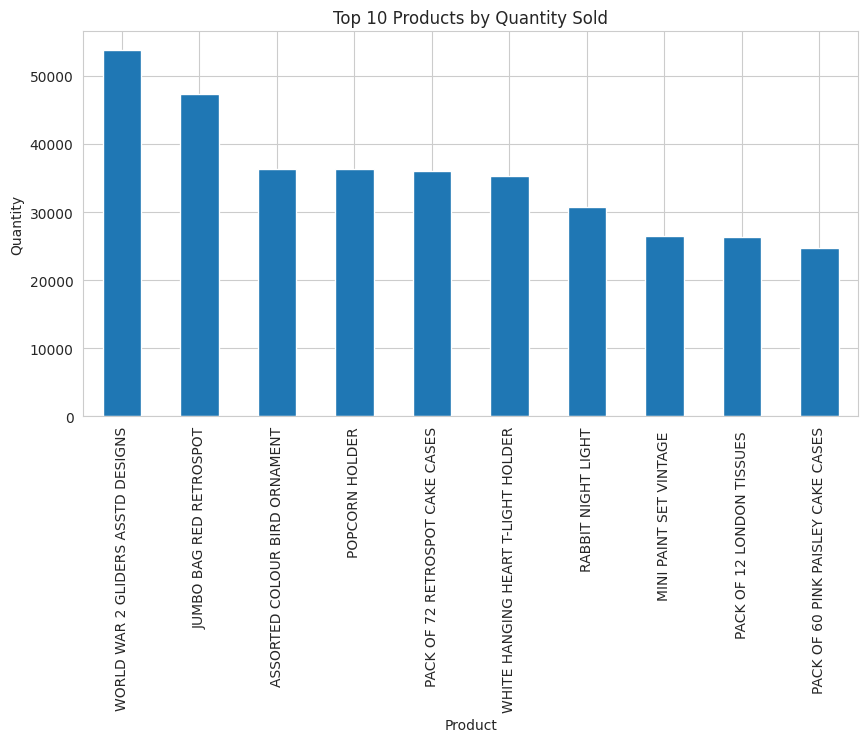

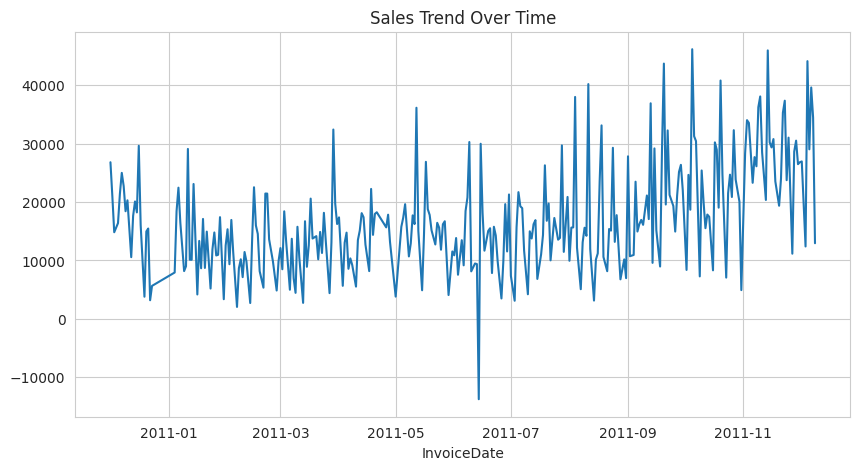

In [7]:
# Top products by quantity
top_products = df1.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Product")
plt.ylabel("Quantity")
plt.show()

# Sales trend (if InvoiceDate exists)
df1['InvoiceDate'] = pd.to_datetime(df1['InvoiceDate'])
df1.groupby(df1['InvoiceDate'].dt.date)['Quantity'].sum().plot(figsize=(10,5))
plt.title("Sales Trend Over Time")
plt.show()

# SCENARIO 2: Hospital (Diabetes)

In [8]:
df2 = pd.read_csv('/kaggle/input/datasets/organizations/uciml/pima-indians-diabetes-database/diabetes.csv')

In [9]:
print(df2.head())
print(df2.info())
print(df2.isnull().sum())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768

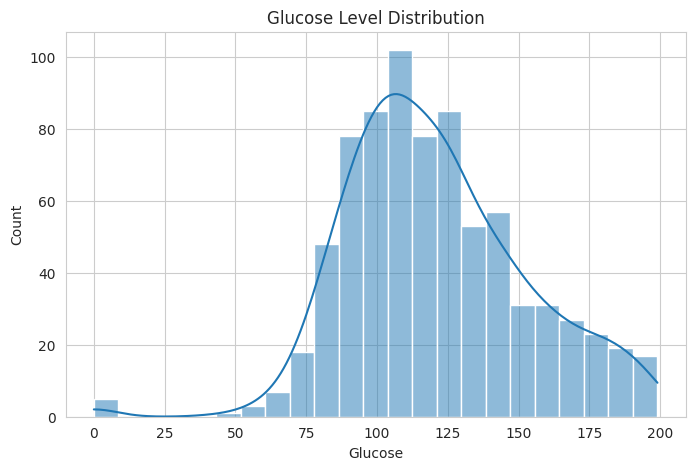

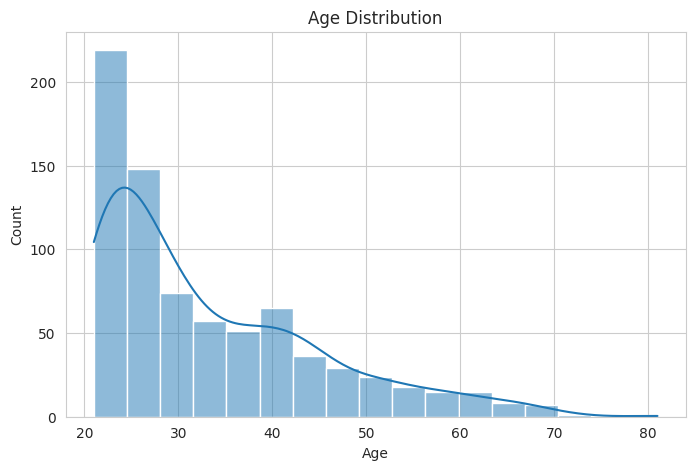

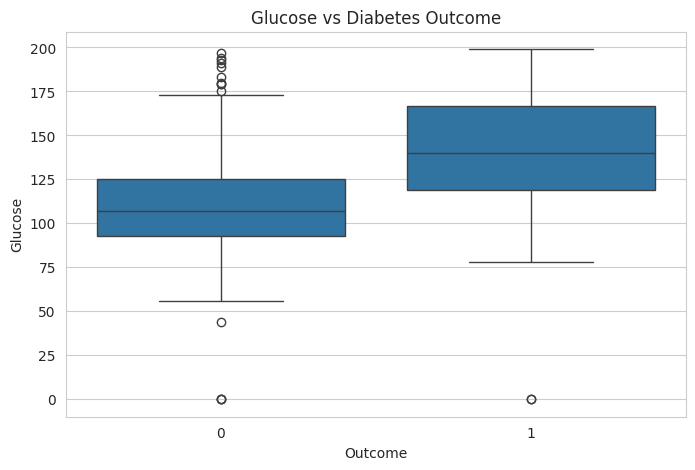

In [10]:
# Glucose distribution
plt.figure(figsize=(8,5))
sns.histplot(df2['Glucose'], kde=True)
plt.title("Glucose Level Distribution")
plt.show()

# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(df2['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

# Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x='Outcome', y='Glucose', data=df2)
plt.title("Glucose vs Diabetes Outcome")
plt.show()

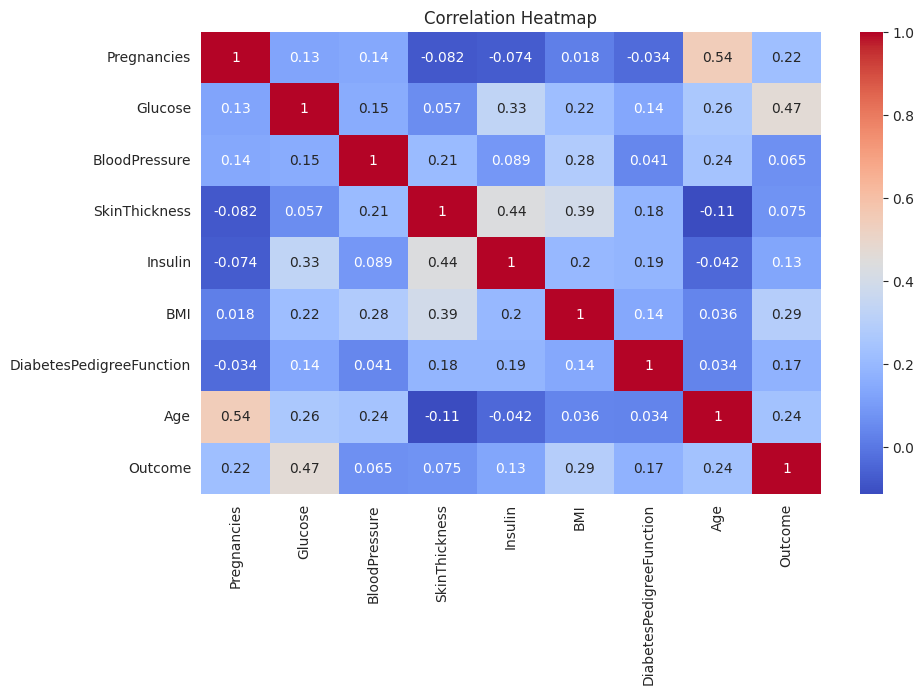

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df2.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# SCENARIO 3: Housing Dataset

In [12]:
df3 = pd.read_csv('/kaggle/input/datasets/harishkumardatalab/housing-price-prediction/Housing.csv')

In [13]:
print(df3.head())
print(df3.info())
print(df3.isnull().sum())

      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 colu

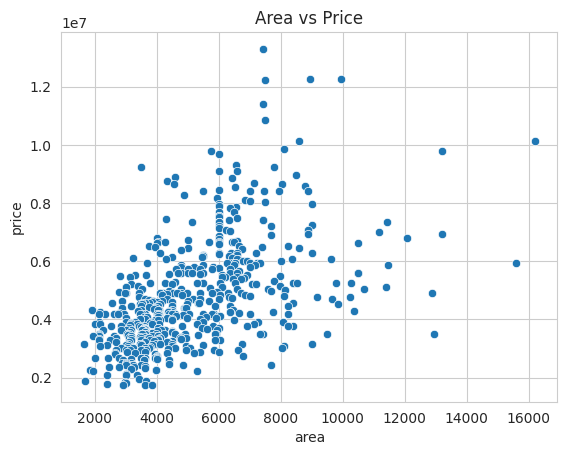

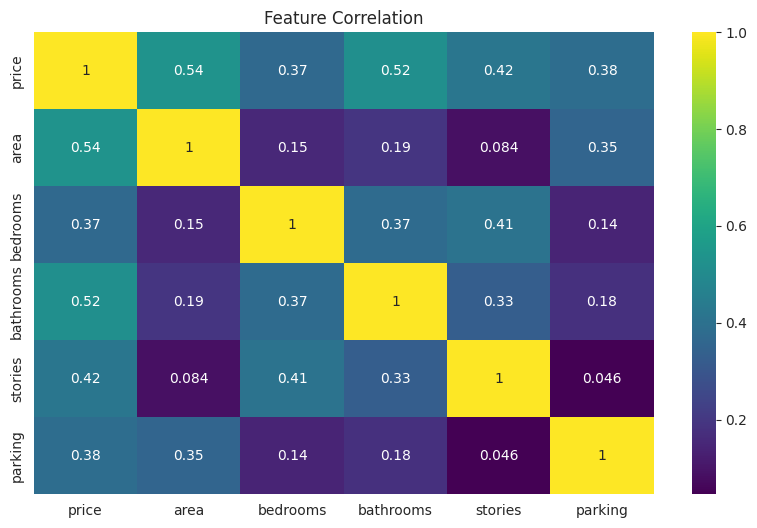

In [16]:
# Scatter plot (example columns)
sns.scatterplot(x='area', y='price', data=df3)
plt.title("Area vs Price")
plt.show()

# Select only numeric columns
numeric_df = df3.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='viridis')
plt.title("Feature Correlation")
plt.show()

# SCENARIO 4: Banking Customer Data

In [17]:
df4 = pd.read_csv('/kaggle/input/datasets/imakash3011/customer-personality-analysis/marketing_campaign.csv', sep='\t')

In [18]:
print(df4.head())
print(df4.info())
print(df4.isnull().sum())

     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
0  04-09-2012       58       635         88              546              172   
1  08-03-2014       38        11          1                6                2   
2  21-08-2013       26       426         49              127              111   
3  10-02-2014       26        11          4               20               10   
4  19-01-2014       94       173         43              118               46   

   MntSweetProducts  MntGoldProds  NumDealsP

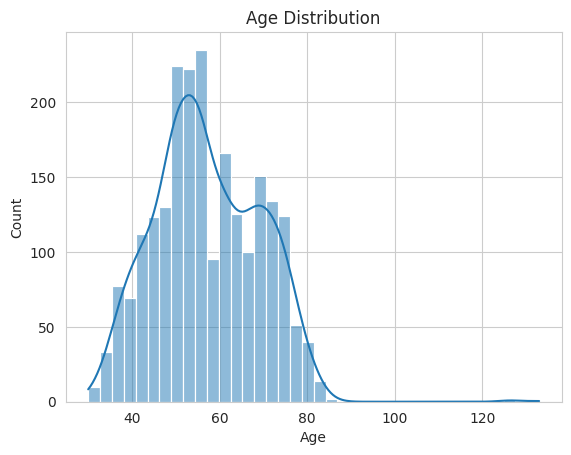

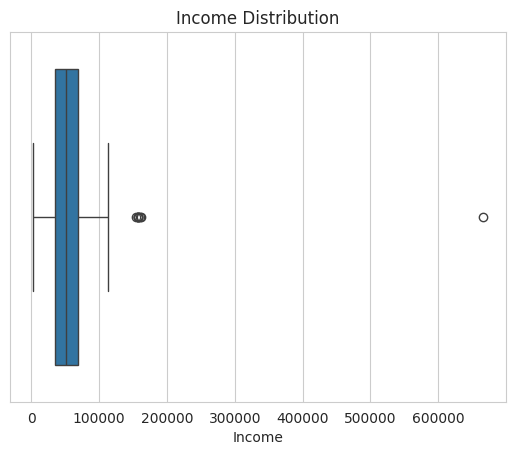

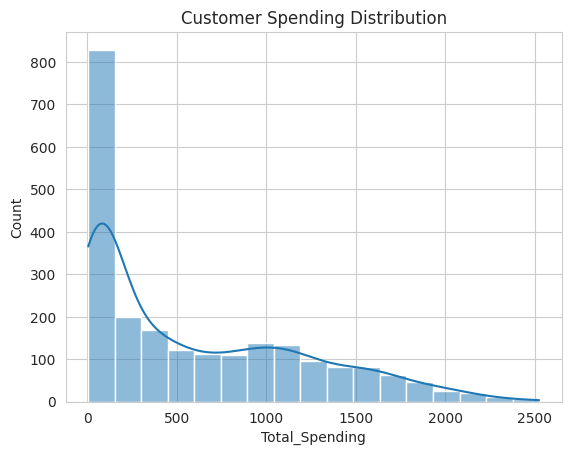

In [19]:
# Age (create from Year_Birth)
df4['Age'] = 2026 - df4['Year_Birth']

# Age distribution
sns.histplot(df4['Age'], kde=True)
plt.title("Age Distribution")
plt.show()

# Income distribution
sns.boxplot(x=df4['Income'])
plt.title("Income Distribution")
plt.show()

# Spending (example: total purchases)
df4['Total_Spending'] = df4[['MntWines','MntFruits','MntMeatProducts',
                            'MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)

sns.histplot(df4['Total_Spending'], kde=True)
plt.title("Customer Spending Distribution")
plt.show()